In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")


Libraries imported successfully


In [2]:
# Load the dataset
df = pd.read_csv("data/insurance.csv")

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Check dataset size
print("Rows and columns:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Rows and columns: (1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check the new dataset size
print("Rows and columns after removing duplicates:", df.shape)

# Check duplicates again
print("Duplicate rows:", df.duplicated().sum())

Rows and columns after removing duplicates: (1337, 7)
Duplicate rows: 0


In [6]:
# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'bmi', 'children', 'charges']

Categorical columns:
['sex', 'smoker', 'region']


C:\Users\baidm\AppData\Local\Temp\ipykernel_20364\1811622258.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


In [7]:
# Descriptive statistics for numerical variables

descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Standard Deviation": df[numeric_cols].std(),
    "IQR": df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25),
    "Skewness": df[numeric_cols].skew(),
    "Kurtosis": df[numeric_cols].kurt()
})

descriptive_stats.round(2)

,Mean,Median,Standard Deviation,IQR,Skewness,Kurtosis
age,39.22,39.00,14.04,24.00,0.05,-1.24
bmi,30.66,30.40,6.10,8.41,0.28,-0.05
children,1.10,1.00,1.21,2.00,0.94,0.20
charges,13279.12,9386.16,12110.36,11911.37,1.52,1.60


Descriptive Statistics Interpretation

Age: The mean age is 39.22 years and the median is 39 years, showing that the age distribution is fairly balanced. The skewness of 0.05 is very close to zero.

BMI: The mean BMI is 30.66 and the median is 30.40. The small positive skewness (0.28) shows a slight right skew.

Children: The mean number of children is 1.10, while the median is 1. The skewness of 0.94 indicates a moderate right-skewed distribution.

Charges: The mean insurance charge is 13,279.12, while the median is 9,386.16. The higher mean compared with the median and skewness of 1.52 indicate a strong right-skewed distribution. The kurtosis of 1.60 also suggests heavier tails.

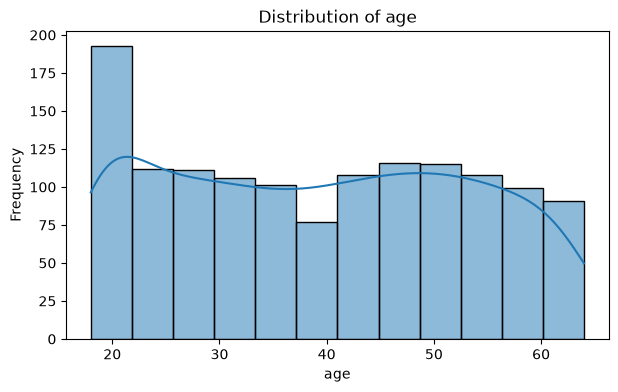

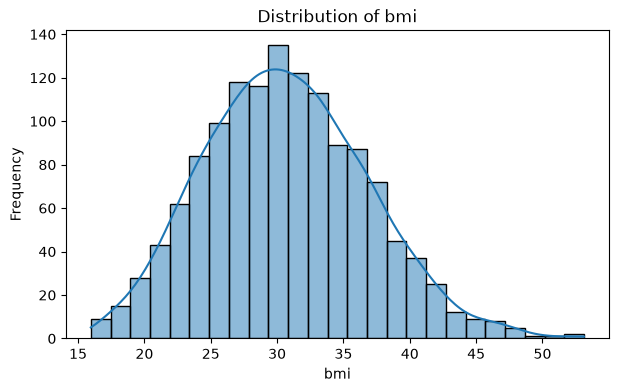

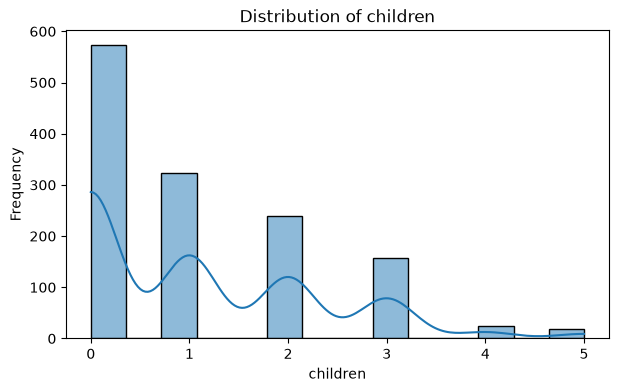

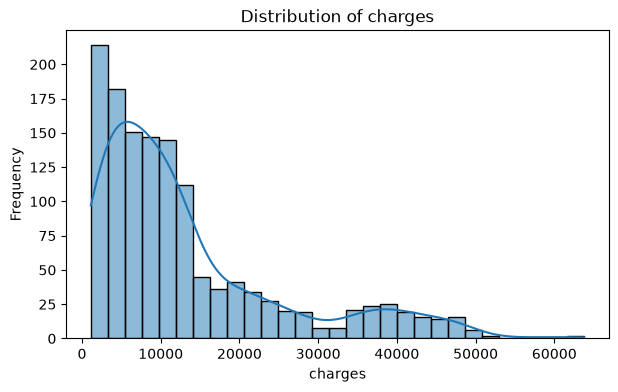

In [8]:
# Histograms with KDE for numerical variables

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

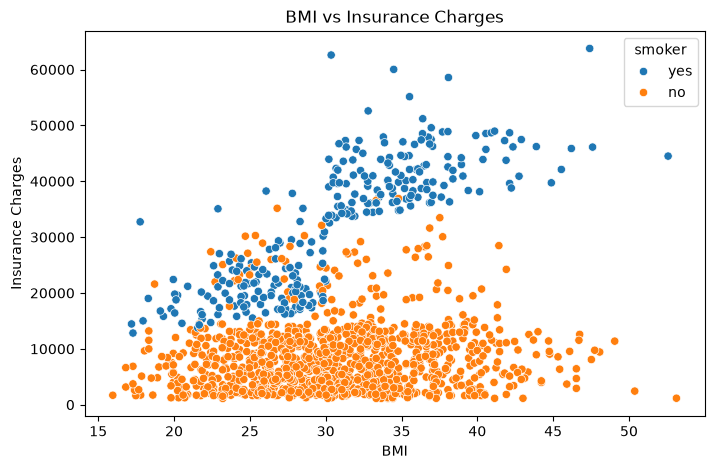

In [9]:
# BMI vs Insurance Charges

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

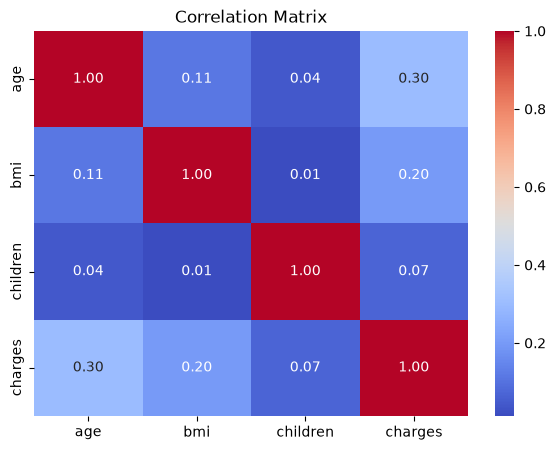

In [10]:
# Correlation matrix for numerical variables

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [11]:
# Display correlation values

correlation_matrix.round(2)

,age,bmi,children,charges
age,1.00,0.11,0.04,0.30
bmi,0.11,1.00,0.01,0.20
children,0.04,0.01,1.00,0.07
charges,0.30,0.20,0.07,1.00


Correlation Analysis

Age and charges have a positive correlation of 0.30, indicating a moderate positive relationship.

BMI and charges have a positive correlation of 0.20, indicating a weak positive relationship.

Children and charges have a very weak positive correlation of 0.07.

Age and BMI have a weak positive correlation of 0.11.

Overall, the numerical variables alone do not show a strong linear relationship with insurance charges. This suggests that categorical variables, especially smoker status, may be important for predicting charges.

In [12]:
# Separate insurance charges into smoker and non-smoker groups

smoker_charges = df[df["smoker"] == "yes"]["charges"]
non_smoker_charges = df[df["smoker"] == "no"]["charges"]

print("Number of smokers:", len(smoker_charges))
print("Number of non-smokers:", len(non_smoker_charges))

print("\nMean charge - Smokers:", round(smoker_charges.mean(), 2))
print("Mean charge - Non-smokers:", round(non_smoker_charges.mean(), 2))

Number of smokers: 274
Number of non-smokers: 1063

Mean charge - Smokers: 32050.23
Mean charge - Non-smokers: 8440.66


In [13]:
# Shapiro-Wilk normality test

shapiro_smoker = stats.shapiro(smoker_charges)
shapiro_non_smoker = stats.shapiro(non_smoker_charges)

print("Shapiro-Wilk Test - Smokers")
print("Statistic:", round(shapiro_smoker.statistic, 4))
print("p-value:", shapiro_smoker.pvalue)

print("\nShapiro-Wilk Test - Non-smokers")
print("Statistic:", round(shapiro_non_smoker.statistic, 4))
print("p-value:", shapiro_non_smoker.pvalue)

Shapiro-Wilk Test - Smokers
Statistic: 0.9396
p-value: 3.624989722535372e-09

Shapiro-Wilk Test - Non-smokers
Statistic: 0.8729
p-value: 1.5035032973570315e-28


In [14]:
# Levene's test for equality of variances

levene_test = stats.levene(smoker_charges, non_smoker_charges)

print("Levene's Test")
print("Statistic:", round(levene_test.statistic, 4))
print("p-value:", levene_test.pvalue)

Levene's Test
Statistic: 332.4714
p-value: 1.6701175651271788e-66


In [15]:
# Mann-Whitney U test

mann_whitney = stats.mannwhitneyu(
    smoker_charges,
    non_smoker_charges,
    alternative="two-sided"
)

print("Mann-Whitney U Test")
print("U statistic:", mann_whitney.statistic)
print("p-value:", mann_whitney.pvalue)

Mann-Whitney U Test
U statistic: 283859.0
p-value: 5.74701188239214e-130


Hypothesis Test 1: Smoker Status vs Insurance Charges

Hypotheses

H₀: There is no significant difference in insurance charges between smokers and non-smokers.

H₁: There is a significant difference in insurance charges between smokers and non-smokers.

Significance level: α = 0.05

Normality Test

The Shapiro-Wilk test was applied to both groups.

Smokers: p-value = 3.62 × 10⁻⁹

Non-smokers: p-value = 1.50 × 10⁻²⁸

Both p-values are less than 0.05, so the normality assumption is rejected.

Equal Variance Test

Levene's test gave:

Statistic = 332.4714

p-value = 1.67 × 10⁻⁶⁶

Since the p-value is less than 0.05, the equal variance assumption is rejected.

Mann-Whitney U Test

Since the data is not normally distributed, the Mann-Whitney U test was used.

U statistic = 283859.0

p-value = 5.747 × 10⁻¹³⁰

Since p-value < 0.05, we reject H₀.

Conclusion

There is a statistically significant difference in insurance charges between smokers and non-smokers. Smokers have a much higher average insurance charge (32,050.23) compared with non-smokers (8,440.66).

In [16]:
# Check insurance charges by region

region_groups = df.groupby("region")["charges"]

print(region_groups.count())

print("\nMean charges by region:")
print(region_groups.mean().round(2))

region
northeast    324
northwest    324
southeast    364
southwest    325
Name: charges, dtype: int64

Mean charges by region:
region
northeast    13406.38
northwest    12450.84
southeast    14735.41
southwest    12346.94
Name: charges, dtype: float64


In [17]:
# One-Way ANOVA for insurance charges across regions

northeast = df[df["region"] == "northeast"]["charges"]
northwest = df[df["region"] == "northwest"]["charges"]
southeast = df[df["region"] == "southeast"]["charges"]
southwest = df[df["region"] == "southwest"]["charges"]

anova_result = stats.f_oneway(
    northeast,
    northwest,
    southeast,
    southwest
)

print("One-Way ANOVA")
print("F statistic:", round(anova_result.statistic, 4))
print("p-value:", anova_result.pvalue)

One-Way ANOVA
F statistic: 2.9261
p-value: 0.03276288025447231


In [18]:
import statsmodels.api as sm
import pandas as pd

# Convert categorical variables
df_model = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

# Separate features and target
X = df_model.drop("charges", axis=1)
y = df_model["charges"]

# Add intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:24:19   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

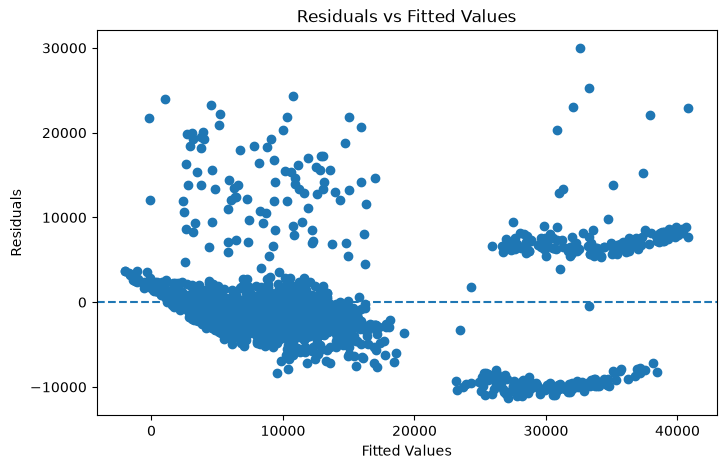

In [19]:
import matplotlib.pyplot as plt

fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

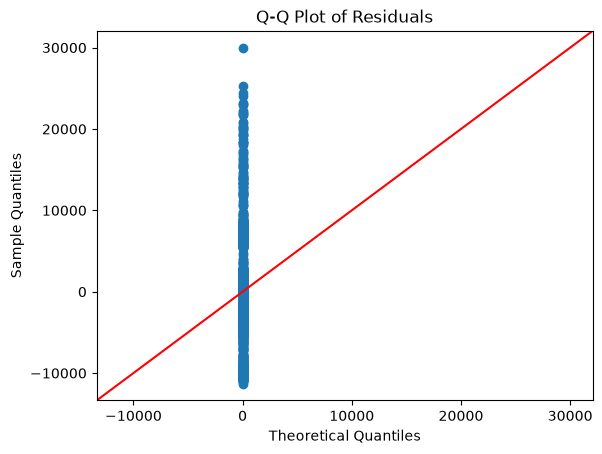

In [20]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(model.resid, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

In [21]:
jb_test = stats.jarque_bera(model.resid)

print("Jarque-Bera Test")
print("Statistic:", round(jb_test.statistic, 4))
print("p-value:", jb_test.pvalue)

Jarque-Bera Test
Statistic: 716.5524
p-value: 2.527045383262612e-156


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

continuous_cols = ["age", "bmi", "children"]

X_vif = df[continuous_cols]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

    Feature       VIF
0       age  1.013754
1       bmi  1.012170
2  children  1.001797


In [23]:
print("R-squared:", round(model.rsquared, 4))
print("Adjusted R-squared:", round(model.rsquared_adj, 4))

jb_test = stats.jarque_bera(model.resid)

print("\nJarque-Bera Statistic:", round(jb_test.statistic, 4))
print("Jarque-Bera p-value:", jb_test.pvalue)

print("\nDurbin-Watson:", round(sm.stats.stattools.durbin_watson(model.resid), 4))

R-squared: 0.7507
Adjusted R-squared: 0.7492

Jarque-Bera Statistic: 716.5524
Jarque-Bera p-value: 2.527045383262612e-156

Durbin-Watson: 2.089


In [24]:
import joblib

model_bundle = {
    "model": model,
    "columns": X.columns.tolist()
}

joblib.dump(model_bundle, "models/insurance_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [25]:
new_data = pd.DataFrame({
    "const": [1],
    "age": [30],
    "bmi": [25],
    "children": [2],
    "sex_male": [1],
    "smoker_yes": [0],
    "region_northwest": [0],
    "region_southeast": [0],
    "region_southwest": [0]
})

prediction = model.get_prediction(new_data).summary_frame(alpha=0.05)

print(prediction)

          mean     mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  5067.799401  440.127361      4204.3787    5931.220102  -6860.134526   

   obs_ci_upper  
0  16995.733329  


In [26]:
print("Predicted Charges:", round(prediction["mean"].iloc[0], 2))
print("95% Confidence Interval:",
      round(prediction["mean_ci_lower"].iloc[0], 2),
      "to",
      round(prediction["mean_ci_upper"].iloc[0], 2))

print("95% Prediction Interval:",
      round(prediction["obs_ci_lower"].iloc[0], 2),
      "to",
      round(prediction["obs_ci_upper"].iloc[0], 2))

Predicted Charges: 5067.8
95% Confidence Interval: 4204.38 to 5931.22
95% Prediction Interval: -6860.13 to 16995.73
